In [1]:
#Importar librearias que se usan
import numpy as np
import matplotlib.pyplot as plt

Sarsa
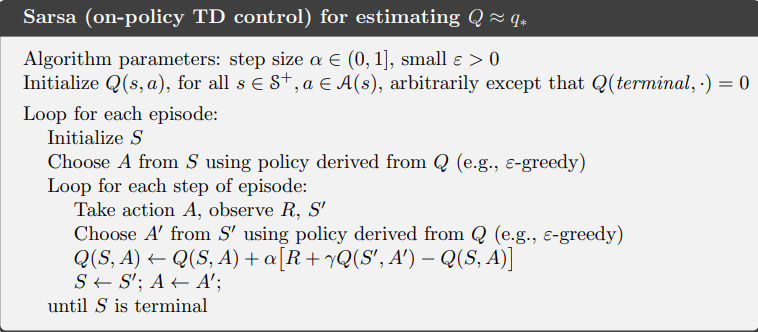

In [81]:
S = 48
sFinales = [47]
allA = [0, 1, 2, 3]
episode = 500
epsilon = 0.1
alpha = 0.3

#rewardsSumSARSA = []
rewardsSumSARSA = np.zeros(episode)

def tomarAccion(sActual, accion):
    fila = sActual // 12
    col = sActual % 12
    sPrima = sActual
    reward = -1
    if accion == 0:
        fila = fila - 1
    elif accion == 1:
        fila = fila + 1
    elif accion == 2:
        col = col - 1
    elif accion == 3:
        col = col + 1

    if fila >= 0 and fila <= 3 and col >= 0 and col <= 11:
        sPrima = fila * 12 + col
    if fila == 3 and col > 0 and col < 11:
      reward = -100
      sPrima = 0
    return sPrima, reward

for j in range(100):
  Q = []
  for s in range(S):
      fila_acciones = [0.0] * 4
      Q.append(fila_acciones)
      #fila_acciones = list(np.random.uniform(-1.0, 1.0, 4)) #Porque son 4 acciones otra vez
      #Q[47] = [0.0, 0.0, 0.0, 0.0]
  for i in range(episode):
    S_actual = 0
    rewardPorEpisodio = 0
    #cKey sera la action escogida con greedy
    cKey = np.random.choice(np.where(Q[S_actual] == np.max(Q[S_actual]))[0])
    randomV = np.random.uniform(0, 1)
    if randomV < epsilon: #Aqui intentara uno aleatorio
      cKey = np.random.randint(0, 4)
    while True:
      sPrima, reward = tomarAccion(S_actual, cKey)
      #cKey sera la action escogida con greedy
      nextKey = np.random.choice(np.where(Q[sPrima] == np.max(Q[sPrima]))[0])
      randomV = np.random.uniform(0, 1)
      if randomV < epsilon: #Aqui intentara uno aleatorio
        nextKey = np.random.randint(0, 4)
      #Actualizacion de Q, S y A
      Q[S_actual][cKey] = Q[S_actual][cKey] + alpha * (reward + Q[sPrima][nextKey] - Q[S_actual][cKey])
      S_actual = sPrima
      cKey = nextKey
      #Guardar acumulado
      rewardPorEpisodio += reward
      if sPrima in sFinales:
        break
    rewardsSumSARSA[i] += rewardPorEpisodio
    #rewardsSumSARSA.append(rewardPorEpisodio)
rewardsSumSARSA = rewardsSumSARSA / 100


Q-Learning
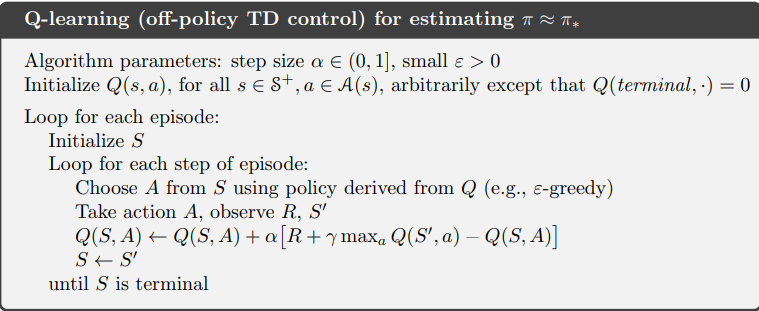

In [82]:
S = 48
sFinales = [47]
allA = [0, 1, 2, 3]
episode = 500

epsilon = 0.1
alpha = 0.3

#rewardsSumQ_Learning = []
rewardsSumQ_Learning = np.zeros(episode)

def tomarAccion(sActual, accion):
    fila = sActual // 12
    col = sActual % 12
    sPrima = sActual
    reward = -1
    if accion == 0:
        fila = fila - 1
    elif accion == 1:
        fila = fila + 1
    elif accion == 2:
        col = col - 1
    elif accion == 3:
        col = col + 1

    if fila >= 0 and fila <= 3 and col >= 0 and col <= 11:
        sPrima = fila * 12 + col
    if fila == 3 and col > 0 and col < 11:
      reward = -100
      sPrima = 0
    return sPrima, reward

for j in range(100):
  Q = []
  for s in range(S):
      fila_acciones = [0.0] * 4
      Q.append(fila_acciones)
  for i in range(episode):
    S_actual = 0
    rewardPorEpisodio = 0
    Q[47] = [0.0, 0.0, 0.0, 0.0]
    while True:
      cKey = np.random.choice(np.where(Q[S_actual] == np.max(Q[S_actual]))[0])
      randomV = np.random.uniform(0, 1)
      if randomV < epsilon: #Aqui intentara uno aleatorio
        cKey = np.random.randint(0, 4)
      sPrima, reward = tomarAccion(S_actual, cKey)

      #Actualizacion de Q, S y A
      Q[S_actual][cKey] = Q[S_actual][cKey] + alpha * (reward + np.max(Q[sPrima]) - Q[S_actual][cKey])

      S_actual = sPrima
      rewardPorEpisodio += reward

      if sPrima in sFinales:
        break
    rewardsSumQ_Learning[i] += rewardPorEpisodio
    #rewardsSumQ_Learning.append(rewardPorEpisodio)
rewardsSumQ_Learning = rewardsSumQ_Learning / 100


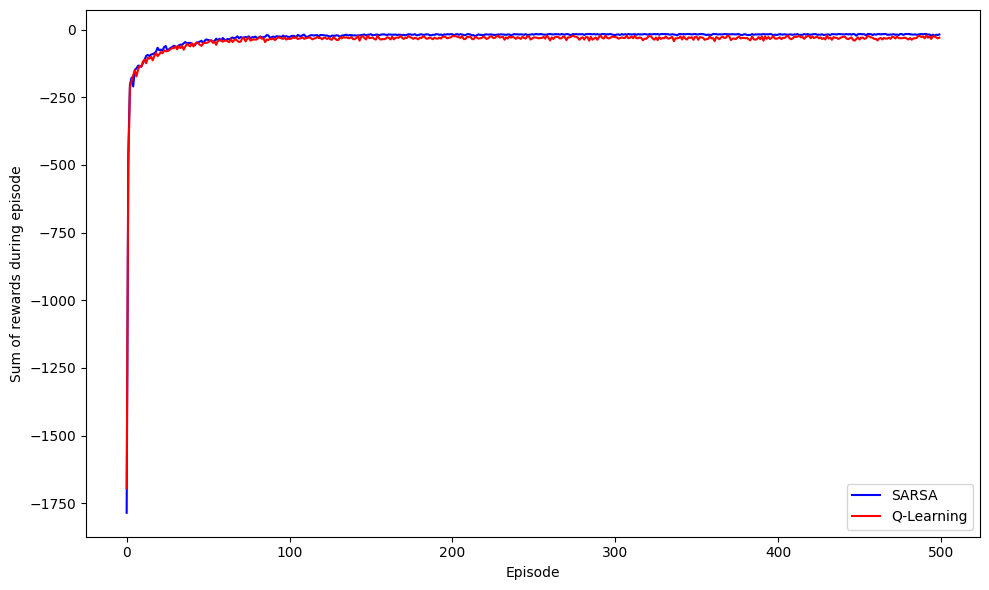

In [83]:
colores = ['blue', 'red']
plt.figure(figsize=(10, 6))

plt.plot(rewardsSumSARSA, label='SARSA', color=colores[0])
plt.plot(rewardsSumQ_Learning, label='Q-Learning', color=colores[1])

plt.xlabel('Episode')
plt.ylabel('Sum of rewards during episode')
plt.legend()

plt.tight_layout()
plt.show()

codigo = https://colab.research.google.com/drive/1wv-64PteXCGdzgZxq6CA-LSVGBUF4e9T?usp=sharing